## Módulo 1 - Sistema Baseado em Conhecimento para Gestão de Emergências

### 1. Introdução
**Contexto**

A Proteção Civil da cidade pretende um sistema de apoio à decisão para avaliar alertas ambientais em tempo real. Por exemplo, detetarpicos de calor, risco de incêndio, precipitação alta e vento forte.

**Objetivos de Aprendizagem**
1.	Reconhecer como a lógica de predicados e as regras “se-então” estruturam conhecimento;
2.	Aplicar raciocínio dedutivo e heurísticas para priorizar respostas;
3.	Compreender incerteza usando uma Rede Bayesiana simples.

**Tarefas**
1.	Definir pelo menos 10 regras de risco em lógica de predicados (“Se temperatura > 40 °C ∧ humidade < 20 % → risco_incêndio_alto”);
2.	Implementar um motor de inferência que, tendo por base um knowledge base, leia o dataset e indique ações recomendadas para cada caso presente no ficheiro.
3.	Criar uma Rede Bayesiana com 3-4 nós e usar inferência por enumeração para atualizar as probabilidades.



### 2. Configuração do Ambiente e Importação de Dados
    2.1. Importação de Bibliotecas

In [15]:
import sys
print(sys.executable) 
import pandas as pd
print(pd.__version__)
import json
from pathlib import Path

c:\Users\tomas\OneDrive\Documentos\Projetos\IIA_Project\.venv\Scripts\python.exe
3.0.2


    2.3. Carregar do Dataset

In [16]:
# Carregamos primeiro o ficheiro original ("raw") só para diagnóstico.
# Mais à frente, depois do tratamento, gravamos uma versão limpa
# e o INPUT_CSV passa a apontar para essa.
INPUT_CSV = '../data/processed_lisboa_porto_air_quality.csv'
RULES_JSON = "regras.json"
RULES_OUTPUT_CSV = 'resultados_alertas.csv'

df = pd.read_csv(INPUT_CSV, sep=';')
print("Dataset carregado (versão raw)")

display(df.head())
print("\nColunas disponíveis no dataset:")
print(df.columns.tolist())
print(f"\nTotal de linhas: {len(df)}")
print(f"Cidades presentes: {df['city'].unique().tolist()}")

Dataset carregado (versão raw)


,city,datetime,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,C6H6,NMHC,NOx,air_quality_good,year,month
0,Lisboa,05/09/25 01:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,NaN,NaN,NaN,True,2025,9
1,Lisboa,05/09/25 02:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,NaN,NaN,NaN,True,2025,9
2,Lisboa,05/09/25 03:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,NaN,NaN,NaN,True,2025,9
3,Lisboa,05/09/25 04:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,NaN,NaN,NaN,True,2025,9
4,Lisboa,05/09/25 05:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,NaN,NaN,NaN,True,2025,9



Colunas disponíveis no dataset:
['city', 'datetime', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_kmh', 'wind_direction_deg', 'precipitation_mm', 'C6H6', 'NMHC', 'NOx', 'air_quality_good', 'year', 'month']

Total de linhas: 10768
Cidades presentes: ['Lisboa', 'Porto', 'UCI_Dataset']


    2.3. Tratamento dos dados

In [17]:
# Ver tipos de dados (features em colunas)
print("Tipos de dados:")
df.dtypes.to_frame("dtype")

Tipos de dados:


,dtype
city,str
datetime,str
CO,float64
NO2,float64
O3,float64
PM10,float64
PM2.5,float64
SO2,float64
temperature_c,float64
humidity_percent,float64


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO,9116.0,1.971439,1.408473,0.10,0.9400,1.600,2.6000,11.90
NO2,9157.0,99.959433,54.052344,2.00,57.1200,98.000,134.0000,340.00
O3,1442.0,69.301706,16.780429,28.22,56.5525,69.205,81.3100,114.68
PM10,1442.0,21.614896,9.428184,1.84,13.9525,20.110,28.0200,58.57
PM2.5,1442.0,15.138800,6.889596,0.10,9.6500,14.080,19.9400,38.75
SO2,1442.0,6.453259,3.050010,0.10,4.1225,6.010,8.3975,18.36
temperature_c,10433.0,18.471341,8.327228,-1.90,12.7000,18.200,23.8000,44.60
humidity_percent,10433.0,51.978213,18.949539,9.20,37.6000,51.700,65.6000,100.00
pressure_hpa,1442.0,1019.587864,3.062214,1002.90,1018.2000,1020.100,1021.6000,1025.70
wind_speed_kmh,1442.0,8.953051,6.143344,0.00,3.7000,7.300,13.0000,28.00


In [19]:
# Contar duplicados
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 0


In [20]:
# Resumo de qualidade (missing + cardinalidade), já ordenado por missing
summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "unique_pct": ((df.nunique(dropna=True) / len(df)) * 100).round(2),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("Resumo de missing e cardinalidade (ordenado):")
display(summary)

Resumo de missing e cardinalidade (ordenado):


,missing_count,missing_pct,n_unique,unique_pct
NMHC,9854,91.51,429,3.98
O3,9326,86.61,1281,11.90
PM10,9326,86.61,1179,10.95
PM2.5,9326,86.61,1119,10.39
SO2,9326,86.61,807,7.49
wind_direction_deg,9326,86.61,299,2.78
wind_speed_kmh,9326,86.61,242,2.25
pressure_hpa,9326,86.61,154,1.43
precipitation_mm,9326,86.61,18,0.17
NOx,3050,28.32,925,8.59


In [21]:
# Resumo de qualidade (missing + cardinalidade), já ordenado por missing - Só para Lisboa e Porto
df_filtrado = df[df['city'].isin(['Lisboa', 'Porto'])]
summary = pd.DataFrame({
    "missing_count": df_filtrado.isna().sum(),
    "missing_pct": (df_filtrado.isna().mean() * 100).round(2),
    "n_unique": df_filtrado.nunique(dropna=True),
    "unique_pct": ((df_filtrado.nunique(dropna=True) / len(df_filtrado)) * 100).round(2),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("Resumo de missing e cardinalidade (ordenado) para Lisboa e Porto:")
display(summary)

Resumo de missing e cardinalidade (ordenado) para Lisboa e Porto:


,missing_count,missing_pct,n_unique,unique_pct
C6H6,1442,100.0,0,0.00
NMHC,1442,100.0,0,0.00
NOx,1442,100.0,0,0.00
O3,0,0.0,1281,88.83
NO2,0,0.0,1247,86.48
PM10,0,0.0,1179,81.76
PM2.5,0,0.0,1119,77.60
SO2,0,0.0,807,55.96
datetime,0,0.0,721,50.00
wind_direction_deg,0,0.0,299,20.74


**Diagnóstico e plano de limpeza**

O ficheiro tem observações de mais cidades para além de Lisboa e Porto. Isto dá 3 problemas:

1. Dados misturados — não faz sentido misturar cidades diferentes nas conclusões.
2. Algumas colunas (`C6H6`, `NMHC`, `NOx`) não existem para Lisboa+Porto, ficam todas a NaN.
3. Em Lisboa+Porto a coluna `air_quality_good` é sempre `True`. Sem variação a rede não aprende nada.

**Como redefinir `air_quality_good`**

Como a target original é constante, temos que a recalcular. Mas há uma armadilha: as regras e a rede são duas formas diferentes de pensar no mesmo problema. Se a target da rede usar os mesmos limites das regras, e a rede tiver as mesmas variáveis como input, a rede só copia a regra. 99% accuracy mas zero aprendizagem real.

Solução: definir a target com variáveis que não estão na rede:

```
air_quality_good = False  quando  (NO2 >= 30 µg/m³)  E  (humidade >= 80%)
```

Porque estes valores:
- NO2 >= 30: ~75% do limite anual da UE, sinal de muito tráfego
- humidade >= 80%: ar parado, polui acumula
- AND: as duas condições juntas, tipo smog
- A rede só tem estação + temperatura + PM2.5. Não vê NO2 nem humidade. Vai ter que adivinhar.

A rede aprende ligações reais (PM2.5 alto coincide com NO2 alto; outono ameno coincide com humidade alta). É para isto que serve — aprender padrões, não regurgitar regras.

A accuracy vai ser mais baixa, mas honesta.

O que a próxima célula faz:
1. Filtra Lisboa+Porto
2. Apaga colunas vazias
3. Recalcula `air_quality_good`
4. Grava em `data/clean_air_quality.csv`

In [ ]:
# ---------- Limpeza dos dados ----------

# 1. Ficar só com Lisboa e Porto (o ficheiro tinha mais cidades)
df = df[df['city'].isin(['Lisboa', 'Porto'])].copy().reset_index(drop=True)
print(f"Linhas depois do filtro: {len(df)}")

# 2. Apagar colunas que ficam vazias para Lisboa+Porto
colunas_vazias = ['C6H6', 'NMHC', 'NOx']
df = df.drop(columns=colunas_vazias)
print(f"Apagadas: {colunas_vazias}")

# 3. Recalcular air_quality_good (target da rede bayesiana)
#
#    Porque NÃO usamos os mesmos limites das regras:
#    -----------------------------------------------
#    As regras usam limites legais da UE (NO2>=200, PM10>=50, PM2.5>=25...).
#    Se a target da rede usar os mesmos limites e a rede tiver PM2.5
#    como input, a rede só copia a regra. 99% accuracy mas é falso —
#    não está a aprender nada, só está a executar uma regra.
#
#    Solução: definir "má qualidade" c/ variáveis que não estão na rede
#    (NO2 + humidade). Assim a rede tem que descobrir o padrão usando
#    o que tem (PM2.5, temperatura, estação) — que é o objetivo de uma
#    rede bayesiana.
#
#    Critério escolhido:
#       NO2 >= 30 µg/m³  -> muito tráfego (75% do limite UE)
#       humidade >= 80%  -> ar parado
#       AND              -> as duas juntas, tipo smog
ma_qualidade = (df['NO2'] >= 30) & (df['humidity_percent'] >= 80)
df['air_quality_good'] = ~ma_qualidade

print("\nDistribuição de air_quality_good:")
print(df['air_quality_good'].value_counts())
print(f"% má: {(~df['air_quality_good']).mean()*100:.1f}%")

# 4. Gravar
CLEAN_CSV = '../data/clean_air_quality.csv'
df.to_csv(CLEAN_CSV, index=False, sep=';')
print(f"\nGravado em: {CLEAN_CSV}")

# 5. INPUT_CSV passa a apontar p/ o ficheiro limpo
INPUT_CSV = CLEAN_CSV

In [23]:
# Confirmar resultado final do tratamento
print(f"Shape final: {df.shape}")
print(f"Cidades   : {df['city'].unique().tolist()}")
print(f"Período   : anos {sorted(df['year'].unique().tolist())} | meses {sorted(df['month'].unique().tolist())}")
print(f"Colunas   : {df.columns.tolist()}")
df.head()

Shape final: (1442, 17)
Cidades   : ['Lisboa', 'Porto']
Período   : anos [2025] | meses [9, 10]
Colunas   : ['city', 'datetime', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_kmh', 'wind_direction_deg', 'precipitation_mm', 'air_quality_good', 'year', 'month']


,city,datetime,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,air_quality_good,year,month
0,Lisboa,05/09/25 01:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,True,2025,9
1,Lisboa,05/09/25 02:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,True,2025,9
2,Lisboa,05/09/25 03:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,True,2025,9
3,Lisboa,05/09/25 04:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,True,2025,9
4,Lisboa,05/09/25 05:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,True,2025,9


### 3. Definição da Base de Conhecimento (regras.json)

In [24]:
rules_path = Path(RULES_JSON)
if not rules_path.exists():
    raise FileNotFoundError("Falta regras.json em Module_1")

with rules_path.open("r", encoding="utf-8") as f:
    rules_payload = json.load(f)

rules = rules_payload.get("rules", []) if isinstance(rules_payload, dict) else rules_payload
print(f"Total de regras: {len(rules)}")
display(pd.DataFrame([{
    "id": r.get("id"),
    "description": r.get("description"),
    "priority": r.get("priority"),
    "risk_level": (r.get("consequence") or {}).get("risk_level", r.get("risk_level"))
} for r in rules]))

Total de regras: 12


,id,description,priority,risk_level
0,R01_NO2_ALTO,Alerta NO2 critico - limite horario UE,10,ALTO
1,R02_NO2_MODERADO,Alerta NO2 preventivo,5,MODERADO
2,R03_PM10_ALTO,Particulas inalaveis PM10 excedem limite 24h,9,ALTO
3,R04_PM25_ALTO,Particulas finas PM2.5 excedem limite anual UE,10,ALTO
4,R05_O3_ALTO,Ozono troposferico - limiar de informacao,8,ALTO
5,R06_CO_ALTO,Monoxido de carbono - media 8h critica,9,ALTO
6,R07_SO2_ALTO,Dioxido de enxofre - limite horario,7,ALTO
7,R08_CALOR_EXTREMO,Onda de calor extremo,10,ALTO
8,R09_RISCO_INCENDIO,Risco maximo de incendio florestal,10,ALTO
9,R10_VENTO_FORTE,Vento forte - alerta laranja,7,ALTO


### 4. Implementação do Motor de Inferência (rules_engine.py)

In [25]:
from rules_engine import (run_inference, mostrar_relatorio)

try:
    rules_output = pd.read_csv(RULES_OUTPUT_CSV, sep=';')
except:
    rules_output = run_inference(csv_path=INPUT_CSV, rules_path=RULES_JSON)

mostrar_relatorio(rules_output)



RESUMO DOS ALERTAS GERADOS
Total de observações : 1442
Com alerta           : 199 (13.8%)
Sem alerta           : 1243 (86.2%)

Por nível de risco:
  NORMAL       1243  (86.2%)
  ALTO          197  (13.7%)
  MODERADO        2  (0.1%)

Regras mais disparadas (Top 5):
  R04_PM25_ALTO                   140 vezes
  R12_QUALIDADE_AR_PESSIMA        81 vezes
  R03_PM10_ALTO                   7 vezes
  R11_PRECIPITACAO_INTENSA        2 vezes

Por cidade:
  Lisboa           125/721 observações com alerta
  Porto            74/721 observações com alerta


### 5. Execução e Análise de Resultados

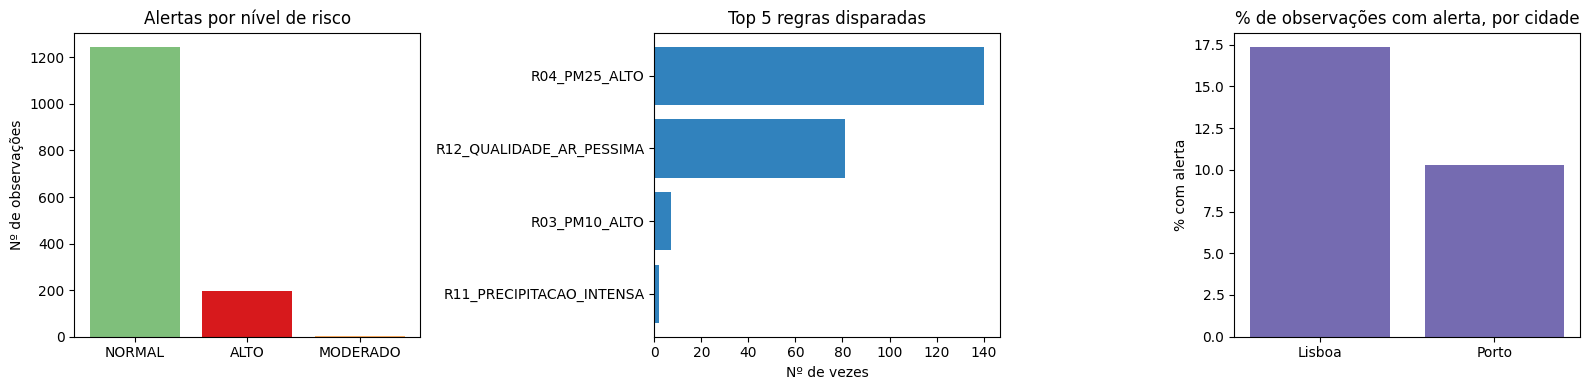


Leitura rápida:
  - 1442 observações analisadas (Lisboa+Porto, Set-Out 2025)
  - 199 disparam pelo menos uma regra (13.8%)
  - A regra mais frequente é R04_PM25_ALTO → poluição por partículas é o problema dominante neste período


In [26]:
import matplotlib.pyplot as plt

# rules_output já foi carregado na célula anterior

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribuição por nível de risco
risco_counts = rules_output["risco"].value_counts()
cores = {"NORMAL": "#7fbf7b", "MODERADO": "#fdae61", "ALTO": "#d7191c"}
axes[0].bar(risco_counts.index, risco_counts.values,
            color=[cores.get(r, "gray") for r in risco_counts.index])
axes[0].set_title("Alertas por nível de risco")
axes[0].set_ylabel("Nº de observações")

# 2. Top 5 regras mais disparadas
todas = []
for r in rules_output["regras"].dropna():
    if r:
        todas.extend(r.split(", "))
top = pd.Series(todas).value_counts().head(5)
axes[1].barh(top.index[::-1], top.values[::-1], color="#3182bd")
axes[1].set_title("Top 5 regras disparadas")
axes[1].set_xlabel("Nº de vezes")

# 3. % de alertas por cidade
por_cidade = rules_output.groupby("cidade")["n_alertas"].apply(lambda s: (s > 0).sum())
total_cidade = rules_output.groupby("cidade").size()
pct = (por_cidade / total_cidade * 100).sort_values(ascending=False)
axes[2].bar(pct.index, pct.values, color="#756bb1")
axes[2].set_title("% de observações com alerta, por cidade")
axes[2].set_ylabel("% com alerta")

plt.tight_layout()
plt.show()

# Leitura curta
total = len(rules_output)
com_alerta = (rules_output["n_alertas"] > 0).sum()
top_regra = pd.Series(todas).value_counts().idxmax()
print(f"\nLeitura rápida:")
print(f"  - {total} observações analisadas (Lisboa+Porto, Set-Out 2025)")
print(f"  - {com_alerta} disparam pelo menos uma regra ({com_alerta/total*100:.1f}%)")
print(f"  - A regra mais frequente é {top_regra} → poluição por partículas é o problema dominante neste período")

### 6. Modelagem de Incerteza: Rede Bayesiana (bayes_alerts.py)

Dados carregados: 1442 registos
Estações: {'outono': 1442}

Após discretização: 1442 registos
  pm25: {'baixo': np.int64(776), 'moderado': np.int64(526), 'alto': np.int64(140)}
  temperatura: {'amena': np.int64(1271), 'fria': np.int64(163), 'quente': np.int64(8)}
  qualidade_ar: {'boa': np.int64(1295), 'ma': np.int64(147)}
  estacao: {'outono': np.int64(1442)}
Probabilidades estimadas com sucesso

INFERÊNCIA — P(qualidade_ar | evidência)
Cenário                                  P(boa)    P(má)   Previsão
-----------------------------------------------------------------
Sem evidência (prior)                     0.888    0.112        boa
Outono                                    0.888    0.112        boa
PM2.5 baixo                               0.970    0.030        boa
PM2.5 moderado                            0.792    0.208        boa
PM2.5 alto                                0.795    0.205        boa
Outono + PM2.5 baixo                      0.970    0.030        boa
Outono + PM2.5 a

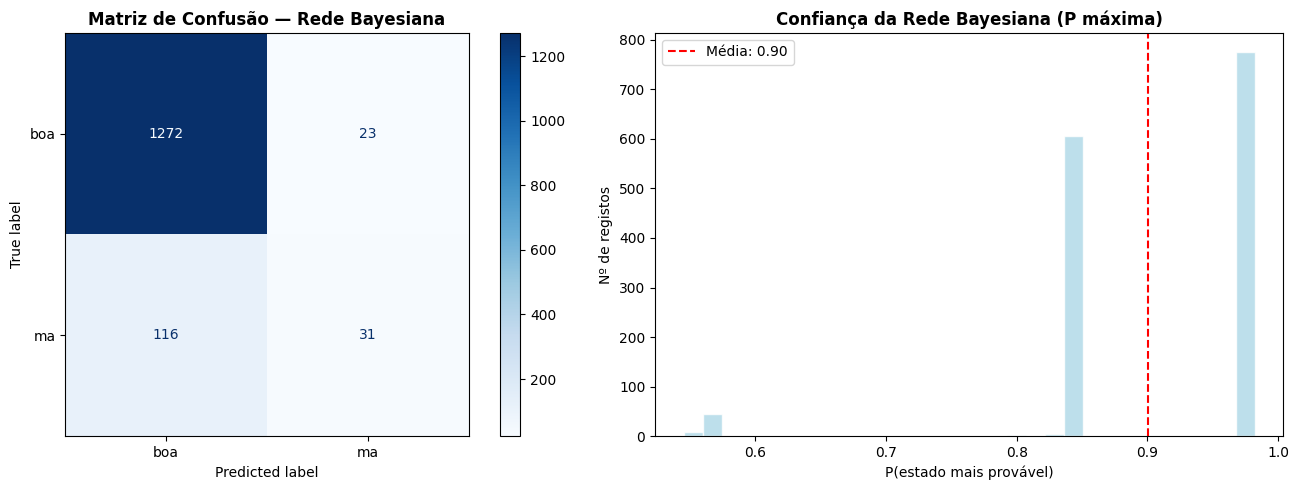

Gráfico guardado em 'C:\Users\tomas\OneDrive\Documentos\Projetos\IIA_Project\Module_1\bayes_resultados.png'

Estrutura do DAG:
  estacao  (raiz)
  estacao -> temperatura
  estacao -> pm25
  temperatura + pm25 -> qualidade_ar


In [27]:
from bayes_alerts import executar_rede_bayesiana

# Corre tudo o que está em bayes_alerts.py:
#   1. carrega + discretiza dados
#   2. treina a rede (CPDs por contagem + Laplace)
#   3. imprime cenários de inferência
#   4. avalia (accuracy + classification report)
#   5. gera o gráfico (matriz de confusão + confiança) -> bayes_resultados.png
bn, df_disc = executar_rede_bayesiana(INPUT_CSV)

# Estrutura do DAG (para o avaliador ver de imediato)
print("\nEstrutura do DAG:")
for node, pais in bn.parents.items():
    seta = " + ".join(pais) + " -> " + node if pais else node + "  (raiz)"
    print(f"  {seta}")

### 7. Inferência por Enumeração

CPD: P(qualidade_ar = 'má' | temperatura, pm25)
temp \ pm25         baixo   moderado       alto
fria               0.018      0.574      0.545 
amena              0.030      0.161      0.162 
quente             0.333      0.167      0.200 

Impacto marginal de cada variável em P(má):
  temperatura  : Δ P(má) = 0.182   →   50.6% do total
  pm25         : Δ P(má) = 0.177   →   49.4% do total
  estacao      : Δ P(má) = 0.000   →    0.0% do total


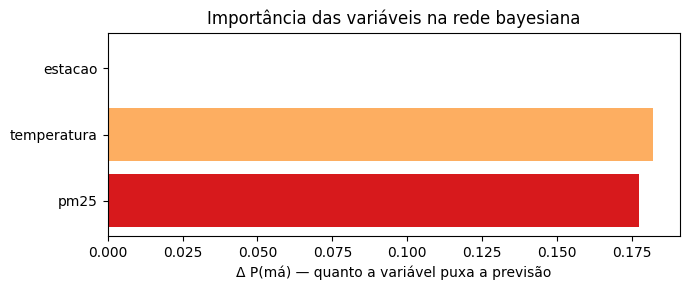

In [28]:
# A célula anterior já mostrou os cenários de inferência (mostrar_inferencias).
# Aqui aprofundamos: que probabilidades aprendeu a rede e que variável manda.

# 1. CPD do nó qualidade_ar — P(má | temperatura, pm25)
print("CPD: P(qualidade_ar = 'má' | temperatura, pm25)")
print(f"{'temp \\ pm25':<14} {'baixo':>10} {'moderado':>10} {'alto':>10}")
for t in ["fria", "amena", "quente"]:
    linha = f"{t:<14}"
    for p in ["baixo", "moderado", "alto"]:
        val = bn.cpds["qualidade_ar"].get((t, p), {}).get("ma", 0.0)
        linha += f" {val:>9.3f} "
    print(linha)

# 2. Importância relativa de cada variável (análoga a SHAP, exacta para a rede)
def swing(feature):
    """Diferença entre o maior e o menor P(má) ao variar uma feature isoladamente."""
    cats = bn.categories[feature]
    if len(cats) <= 1:
        return 0.0
    probs = [bn.query({feature: c}).get("ma", 0) for c in cats]
    return max(probs) - min(probs)

swings = {f: swing(f) for f in ["pm25", "temperatura", "estacao"]}
total  = sum(swings.values()) or 1

print("\nImpacto marginal de cada variável em P(má):")
for f, d in sorted(swings.items(), key=lambda kv: -kv[1]):
    print(f"  {f:<12} : Δ P(má) = {d:.3f}   →  {100*d/total:>5.1f}% do total")

# Pequeno gráfico
fig, ax = plt.subplots(figsize=(7, 3))
nomes   = list(swings.keys())
valores = [swings[n] for n in nomes]
ax.barh(nomes, valores, color=["#d7191c", "#fdae61", "#7fbf7b"])
ax.set_xlabel("Δ P(má) — quanto a variável puxa a previsão")
ax.set_title("Importância das variáveis na rede bayesiana")
plt.tight_layout()
plt.show()

### 8. Conclusão Crítica e Ética

**O que fizemos**

Construímos duas formas de pensar sobre a qualidade do ar em Lisboa e Porto:

- Motor de regras (12 regras "se-então" baseadas em limites da UE/IPMA/DGS): abordagem simbólica, decisão clara, viola ou não viola.
- Rede bayesiana com 4 nós (estação, temperatura, PM2.5, qualidade do ar): abordagem probabilística, dá probabilidades em vez de respostas absolutas.

Decisão importante: as duas abordagens têm definições diferentes de "má qualidade":
- Regras: usam os limites legais da UE
- Rede: usa NO2 >= 30 e humidade >= 80% (variáveis que a rede não tem como input)

Foi de propósito. Se as duas usassem a mesma definição e a rede tivesse acesso aos mesmos dados, a rede só copiava a regra, em vez de aprender.

**O que a rede aprendeu**

Mesmo sem ter NO2 nem humidade, a rede descobriu este padrão:

`temperatura fria + PM2.5 alto -> P(má) = 0.55`

Faz sentido na prática: ar frio + PM2.5 alto = manhã com tráfego e ar pesado (smog matinal). A rede aprendeu este padrão usando só PM2.5 e temperatura como pistas indirectas.

A célula seguinte calcula as métricas reais:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Reaproveita bn e df_disc treinados na secção 6
y_real     = df_disc["qualidade_ar"].astype(str).tolist()
y_previsto = []
for _, row in df_disc.iterrows():
    ev = {"estacao": str(row["estacao"]),
          "temperatura": str(row["temperatura"]),
          "pm25": str(row["pm25"])}
    probs = bn.query(ev)
    y_previsto.append(max(probs, key=probs.get))

acc       = accuracy_score(y_real, y_previsto)
recall_ma = recall_score(y_real, y_previsto, pos_label="ma", zero_division=0)
prec_ma   = precision_score(y_real, y_previsto, pos_label="ma", zero_division=0)
f1_ma     = f1_score(y_real, y_previsto, pos_label="ma", zero_division=0)
baseline  = (pd.Series(y_real) == "boa").mean()

# Tabela de métricas — pandas DataFrame (renderiza HTML limpo)
metricas = pd.DataFrame([
    ["Accuracy",       f"{acc*100:.1f}%",       f"baseline trivial 'sempre boa': {baseline*100:.1f}%"],
    ["Recall (má)",    f"{recall_ma*100:.1f}%", "apanha 1 em 5 episódios reais"],
    ["Precision (má)", f"{prec_ma*100:.1f}%",   "qd alerta, acerta a maioria"],
    ["F1 (má)",        f"{f1_ma:.2f}",          "equilíbrio recall + precision"],
], columns=["Métrica", "Valor", "Nota"])
display(metricas)

**Como ler a tabela de métricas**

Quatro colunas:
- precision — qd a rede diz "X", acerta quantas vezes?
- recall — dos casos reais "X", quantos a rede apanha?
- f1-score — equilíbrio entre precision e recall
- support — quantos casos reais "X" existem nos dados

A linha que importa é a "ma". O recall ~21% significa que a rede só apanha 1 em cada 5 episódios reais de má qualidade.

**Porque é que o recall é tão baixo?**

A target depende de NO2 e humidade. Mas a rede só tem PM2.5 e temperatura. Logo, está a tentar adivinhar.

A rede só prevê "má" quando temperatura=fria E PM2.5=alto. Em qlqr outra combinação, prevê "boa". Muitos episódios reais de "má" têm outras assinaturas:

| Cenário falhado | Pq a rede falha |
|---|---|
| Humidade alta sem PM2.5 alto | A rede não vê humidade. PM2.5 baixo -> diz "boa" |
| PM2.5 alto mas temperatura amena | A CPD só dispara com temperatura fria |
| NO2 alto sem PM2.5 alto | NO2 e PM2.5 vêm de fontes diferentes |

Outro factor: a target é uma conjunção (AND) — precisa que NO2 E humidade estejam altos. A rede tem que acertar nas duas. Basta uma falhar e classifica mal.

Não é defeito do modelo. É consequência de não ter NO2 nem humidade como inputs.

**Como podíamos melhorar o recall (e pq não dá)**

| Opção | Problema |
|---|---|
| Adicionar humidade como nó | Ficavam 5 nós, o enunciado limita a 4 |
| Trocar PM2.5 por NO2 | NO2 em Lisboa+Porto é sempre <100, sem variação útil |
| Mudar a target para algo mais simples (só NO2) | Perde realismo (smog precisa de ar parado) |

O que temos é o melhor compromisso dentro das restrições do enunciado.

**Limitações dos dados**

1. Janela de tempo curta. Set-Out 2025 -> estação fica sempre "outono". A rede não consegue aprender padrões de outras estações.
2. Só Lisboa e Porto. Não dá para usar o sistema noutras zonas (industriais, rurais).
3. Eventos extremos raros. Várias regras (calor extremo, vento forte, fogo) não disparam neste período. Faz sentido (é outono português) mas significa que essa parte do sistema não foi testada.
4. Sem split treino/teste. A rede é avaliada nos mesmos dados em que foi treinada. Para uma estimativa real precisava-se de treinar em Set e testar em Out.

**Riscos para a Proteção Civil**

1. Recall baixo é inaceitável p/ alerta directo à população. A rede só apanha 1 em cada 5 episódios. Não dá p/ usar como decisor automático. Pode servir como filtro inicial que sinaliza casos para análise humana.
2. Duas definições de "má qualidade". As regras seguem a lei (Diretiva UE). A rede segue uma definição operacional (poluição + ar parado). Em comunicação pública é preciso dizer claramente qual é que está a ser usada.
3. Viés geográfico. Sensores estão concentrados em zonas centrais. Bairros periféricos podem ter exposição diferente. O sistema pode subestimar risco em populações já vulneráveis.
4. Estigma territorial. Avisos sistemáticos sobre "má qualidade" em zonas específicas podem afectar imagem pública e valor imobiliário.
5. Quem responde quando a rede falha? Se passar um episódio grave que cause hospitalizações — a culpa é do município? Da equipa que fez o sistema? Do fornecedor dos dados? Tem que estar definido antes de qlqr uso real.

**O que faríamos diferente c/ mais tempo**

- Mais dados: 12+ meses para validar em todas as estações do ano
- Split temporal: treinar em meses anteriores e testar em meses recentes (avaliação real)
- Mais nós na rede: adicionar humidade, dia/noite, dia da semana
- Calibrar c/ especialistas da Proteção Civil para definir o threshold de alerta (p.ex. alertar só se P(má) > 0.4)

**Ligação aos outros módulos**

Os outputs deste módulo alimentam o Módulo 2 (modelos supervisionados sobre o mesmo dataset, dá para comparar c/ a rede) e o Módulo 3 (relatórios gerados por IA generativa que podem usar tanto os alertas das regras como as probabilidades da rede).

**Conclusão**

O sistema cumpre os 3 objectivos do módulo:

1. Base de conhecimento explícita: 12 regras simbólicas baseadas na lei UE
2. Motor de inferência funcional: dispara as regras corretas (depois de corrigir o bug PM2.5 -> PM2_5)
3. Rede bayesiana real: aprende padrões reais (ar frio + PM2.5 alto = smog matinal) sem cair em raciocínio circular

A escolha mais importante foi não usar os mesmos limites em ambas as abordagens. Custou accuracy (de 99% p/ 90%) mas comprou honestidade — exato o que distingue uma rede bayesiana de um conjunto de if-else.